<a href="https://colab.research.google.com/github/piaseckazaneta/30DayMapChallenge2026/blob/main/Day4_2026_Clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import sys
import os
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Montowanie Google Drive
drive.mount('/content/drive')

# 2. Ścieżka do Twojego folderu projektu
PROJECT_DIR = '/content/drive/MyDrive/30daymapchallenge2026_Warsaw_pipeline/'

# Dodajemy folder do sys.path, żeby Python widział layout_engine.py
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

# 3. Importujemy nasz layout
from layout_engine import setup_linkedin_canvas, finalize_and_save_linkedin_map

Mounted at /content/drive


In [2]:
# 4. Ścieżka do danych
DATA_DIR = f"{PROJECT_DIR}/Data"

# Wczytanie bazy w metrach (EPSG:2180)
pipeline_gdf = gpd.read_parquet(f"{DATA_DIR}/warszawa_retail_pipeline_final.parquet").to_crs(2180)

# 5. Wydzielenie punktów sieci własnej (50 placówek)
own_stores_pts = pipeline_gdf[pipeline_gdf['has_own_store'] == True].copy()
own_stores_pts['geometry'] = own_stores_pts.geometry.centroid

In [5]:
!pip install -q osmnx
import osmnx as ox
# 6. Pobieramy oficjalną granicę administracyjną Warszawy jako poligon
# Używamy geocodingu OSMnx
warszawa_admin = ox.geocode_to_gdf("Warszawa, Poland")

# 7. Bardzo ważne: reprojekcja do naszego układu metrycznego!
warszawa_admin = warszawa_admin.to_crs("EPSG:2180")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.3 MB/s eta 0:00:00


[Export] Saved clean executive map to: day_04_hexagons_warsaw.png


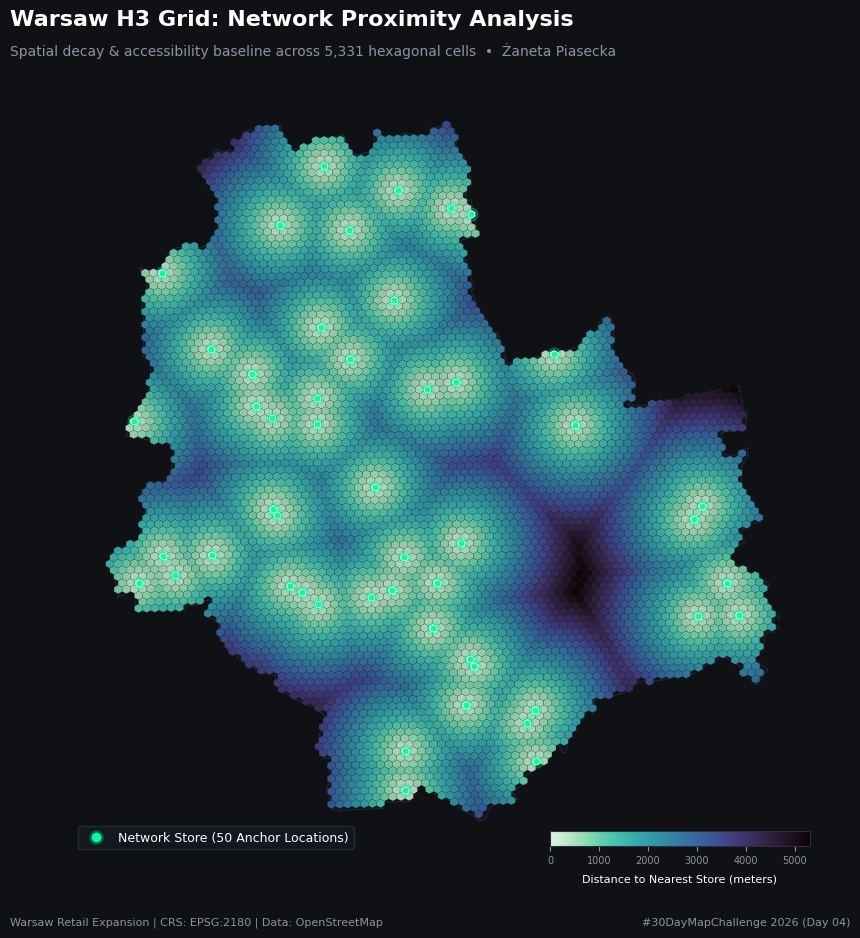

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from layout_engine import setup_linkedin_canvas, finalize_and_save_linkedin_map

# 1. Inicjalizacja canvasu
fig, ax = setup_linkedin_canvas(aspect_ratio="square")

# Warstwa 0: Obrys administracyjny
warszawa_admin.plot(
    ax=ax,
    facecolor="#12141A",
    edgecolor="#222733",
    linewidth=0.8,
    zorder=1
)

# Warstwa 1: Siatka heksagonów H3 pokolorowana według odległości
# Wskazówka: kolumna do wizualizacji to 'dist_to_own_store_m'
hex_plot = pipeline_gdf.plot(
    ax=ax,
    column="dist_to_own_store_m",
    cmap="mako_r",              # Odwrócona paleta mako: ciemny = blisko, jasny = daleko
    linewidth=0.1,
    edgecolor="#161920",
    alpha=0.9,
    zorder=2
)

# Warstwa 2: Sklepy naszej sieci (Glow + Rdzeń) na wierzchu
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    markersize=90,
    alpha=0.25,
    zorder=3
)
own_stores_pts.plot(
    ax=ax,
    color="#00FFA3",
    edgecolor="#FFFFFF",
    linewidth=0.5,
    markersize=25,
    alpha=0.95,
    zorder=4
)

# 3. Dodajemy profesjonalny pasek skali barwnej (Colorbar)
# Tworzymy małą, dedykowaną oś wewnątrz canvasu: [x, y, szerokość, wysokość]
cax = fig.add_axes([0.62, 0.12, 0.26, 0.015])
sm = plt.cm.ScalarMappable(
    cmap="mako_r",
    norm=plt.Normalize(
        vmin=pipeline_gdf['dist_to_own_store_m'].min(),
        vmax=pipeline_gdf['dist_to_own_store_m'].max()
    )
)
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Distance to Nearest Store (meters)', color='#FFFFFF', fontsize=8, labelpad=6)
cbar.ax.tick_params(labelsize=7, colors='#8A94A6')
cbar.outline.set_edgecolor('#2A2F3D')

# 4. Dyskretna legenda dla punktów sklepów w lewym dolnym rogu
mint_hex = "#00FFA3"
mint_glow_rgba = to_rgba(mint_hex, alpha=0.30)

custom_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=f'Network Store ({len(own_stores_pts)} Anchor Locations)',
        markerfacecolor=mint_hex,
        markeredgecolor=mint_glow_rgba,
        markeredgewidth=3.5,
        markersize=7.0
    )
]

legend = ax.legend(
    handles=custom_handles,
    loc="lower left",
    frameon=True,
    facecolor="#161920",
    edgecolor="#2A2F3D",
    fontsize=9,
    labelcolor="#FFFFFF"
)
legend.get_frame().set_alpha(0.85)

# 5. Finalizacja i eksport
finalize_and_save_linkedin_map(
    fig=fig,
    ax=ax,
    main_title="Warsaw H3 Grid: Network Proximity Analysis",
    subtitle="Spatial decay & accessibility baseline across 5,331 hexagonal cells",
    author_name="Żaneta Piasecka",
    day_num=4,
    output_filename="day_04_hexagons_warsaw.png"
)

plt.show()